# Perceptron
The Perceptron is a **linear classifier** used for **binary classification**.

# Brief History
The first model of **artificial neuron** was introduced by McCulloch and Pitts in 1943 (see [resources](#resources) at the end).
The Perceptron algorithm was first proposed by Frank Rosenblatt in 1957 and it is one of the first examples of **artificial neural network**. Technically, the original version is considered a **single-layer neural network**, but it has been extended later on.

# The Rosenblatt Algorithm
The original algorithm for **supervised learning** of the Perceptron follows:
1. Initialize the weights $\boldsymbol w$ to zero or to a small random value.
2. For each learning epoch (indicated by argument $t$):
    1. For each element $(\boldsymbol x_i, y_i)$ of the training set, with $\boldsymbol x_i$ input vector and $y_i$ desired output, do:
        1. Compute output with current weights $\boldsymbol w(t)$: $y_i'(t) = H(\boldsymbol w(t) \cdot \boldsymbol x_i)$ .
        2. Update the weights based on the difference between the predicted output and the desired one: $\boldsymbol w(t + 1) = \boldsymbol w(t) + \eta (y_i - y_i'(t))\boldsymbol x_i$ .
    2. Check if the iteration error $\frac{1}{S}\sum_{i=1}^S |y_i - y_i'(t)|$ is less then a fine-tuned error threshold $\gamma$.

This algorithm has a major problem: it can only work on **linearly separable datasets**. This means that, given an $N$-dimensional dataset, an $N-1$-dimensional hyperplane that separates the samples in two distinct classes must exist, otherwise other classifiers are needed (e.g. SVMs). Moreover, notice that the weights are left unchanged in a learning epoch if $y_i = y_i'(t)$ .

# Extensions to Multiclass Classification
While there are different methods to extend the Perceptron algorithm for multiclass classification, one of the easiest methods is to employ the OVA (One-Versus-All) strategy (see related notes).

# Example
Let's apply the Rosenblatt algorithm to a very well-known dataset, the **breast cancer Wisconsin dataset**. It is characterized by the following properties:
<table style="margin-left: auto; margin-right: auto;">
    <tr>
        <th>Classes</th>
        <td>2</td>
    </tr>
    <tr>
      <th>Samples per class</th>
      <td>212(M), 357(B)</td>
    </tr>
    <tr>
      <th>Samples total</th>
      <td>569</td>
    </tr>
    <tr>
      <th>Dimensionality</th>
      <td>30</td>
    </tr>
    <tr>
      <th>Features</th>
      <td>real, positive</td>
    </tr>
</table>

In [7]:
%matplotlib inline
from sklearn.datasets import load_breast_cancer # For the dataset
from sklearn.model_selection import train_test_split # For splitting the entire dataset in learning and testing subsets
from sklearn.metrics import confusion_matrix, classification_report # For classification evaluation
from sklearn.preprocessing import StandardScaler # For data standardization
from mlpack.perceptron import Perceptron # Perceptron class
from mlpack.model import VerbosityLevel
import matplotlib.pyplot as plt # For plotting the loss function

# Load dataset
X, y = load_breast_cancer(return_X_y = True)

sc = StandardScaler()
X = sc.fit_transform(X=X, y=y)
print(X)
print

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3,   # Set proportion of the dataset to include in the testing subset 
    random_state = 42  # Set seed of random generator in order to ensure reproducibility of the results
)

# Instantiate Perceptron object
clf = Perceptron(
    bias = 0,
    learning_rate = 0.3,
    patience = 1000,
    tolerance = 1e-3,
    verbosity = VerbosityLevel.DEBUG,
)

# Apply Rosenblatt algorithm to the training subset
clf.fit(X_train, y_train)

# Classify the testing subset
pred = clf.predict(X_test)

# Print sklearn's classification report and the confusion matrix in order to evaluate the learning results
print("==== Classification report ====")
print(classification_report(y_test, pred))

print("==== Confusion matrix ====")
print(confusion_matrix(y_test, pred))

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]
Epoch: 1
	Loss : 1731.8121
	Score: 0.1474
Epoch: 2
	Loss : 827.6023
	Score: 0.2179
Epoch: 3
	Loss : 0.0000
	Score: 0.5566
Epoch: 4
	Loss : 0.0000
	Score: 0.8390
Epoch: 5
	Loss : 0.0000
	Score: 0.8880
Epoch: 6
	Loss : 0.0000
	Score: 0.9084
Epoch: 7
	Loss : 0.0000
	Score: 0.9221
Epoch: 8
	Loss : 0.0000
	Score: 0.9265
Epoch: 9
	Loss : 0.0000
	Score: 0.9287
Epoch: 10
	Loss : 0.0000
	Score: 0.9325
Epoch: 11
	Loss : 0.0000
	Score: 0.9347
Epoch: 12
	Loss : 0.0000
	Score: 0.9369
Epoch: 13
	Loss : 0.0000
	Score: 0

/home/fcp/arc/dev/machine_learning/mlpack/mlpack/linear_classifier.py:268: UserWarning: Convergence wasn't reached within the specified number of epochs!
  warnings.warn("Convergence wasn't reached within the specified number of epochs!")


# Loss Function
One can use the following function as the Perceptron's loss function:
$$
l(\boldsymbol w, X, \boldsymbol y) = \max (\boldsymbol 0, -\boldsymbol y \cdot (X \boldsymbol w))
$$
where $\boldsymbol 0$ is a null vector and $\boldsymbol y$ is a vector of two values: $-1$ and $+1$. However, there is a catch. The Rosenblatt algorithm expects labels with values $0$ and $+1$. Therefore, the formula to use is:
$$
l(\boldsymbol w, X, \boldsymbol y) = \boldsymbol 1^T \max (\boldsymbol 0, -\boldsymbol (2y - 1) \cdot (X \boldsymbol w))
$$
Where $\boldsymbol 1$ is a vector of ones and implements mathematically a summation along all features' dimensions.

In particular, the library allows to see the loss function evolution over training epochs of a classifier using the `plot_loss_curve()` method.

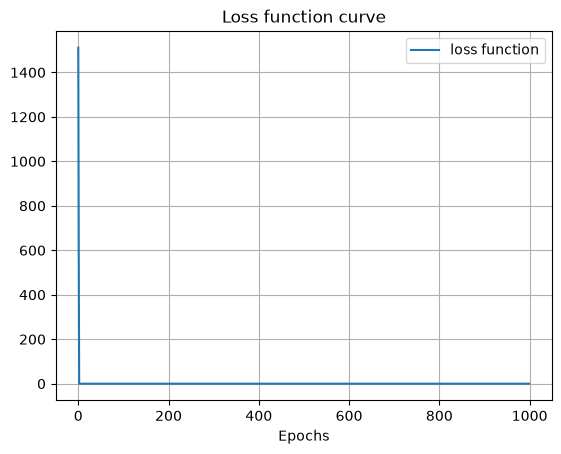

In [4]:
# Visualize loss function
clf.plot_loss_curve(label="loss function")

plt.show()

# Resources
<a id='resources'></a>
- The relevant [Wikipedia page](https://en.wikipedia.org/wiki/Perceptron).
- Wikipedia page on the [first neural networks](https://en.wikipedia.org/wiki/History_of_artificial_intelligence#Perceptrons_and_early_neural_networks).
- "[A Logical Calculus of the Ideas Immanent in Nervous Activity](https://en.wikipedia.org/wiki/A_Logical_Calculus_of_the_Ideas_Immanent_in_Nervous_Activity)" by W.S.McCulloch and W.Pitts (1943): the paper which introduced the first model of artificial neuron.
- Medium article on [Perceptron loss function](https://medium.com/@noorfatimaafzalbutt/understanding-perceptron-loss-function-hinge-loss-binary-cross-entropy-and-the-sigmoid-function-bbb42d128ef6).